## Bag of Words (BOW)

Bag of Words (BOW) is a simple and classic text preprocessing technique used to convert text paragraphs into numbers based on word frequency (counts).


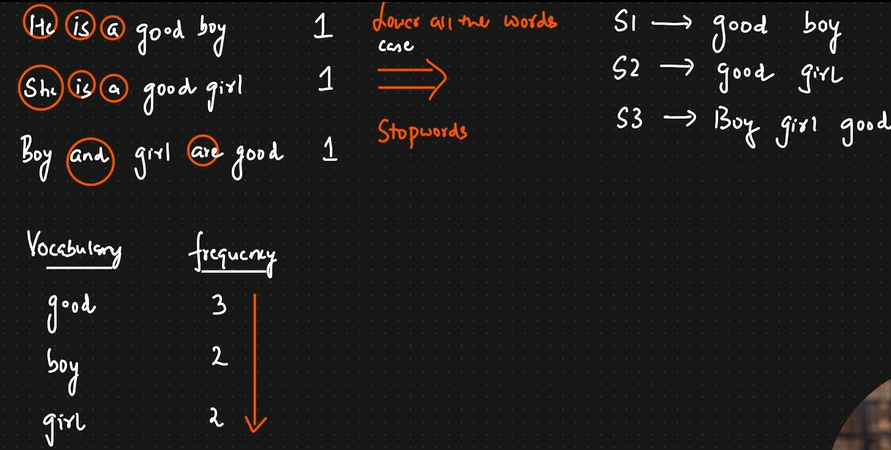
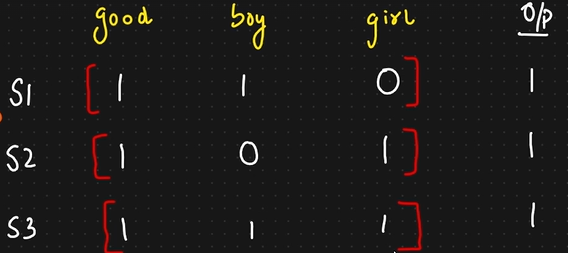


### Visual Example of How It Works

Imagine you have a small dataset with two sentences:

"The cat chased the rat."

"The rat chased the cat."

### Step 1: Create the Vocabulary List

First, the algorithm extracts every unique word across all sentences to build a master dictionary index:

['cat', 'chased', 'rat', 'the'] (Length: 4 unique words)


### For removing stopwords , It depends your case.
- Keep Stop Words if: Sentence meaning changes drastically when you delete words like "not", "no", or "never".

- Remove Stop Words if: You only care about the core keywords to figure out the general topic of the text.

### Step 2: Count the Words (The Vectors)

Now, it creates a row of counts for each sentence matching the master dictionary columns:

| Sentence | cat | chased | rat | the |
|----------|-----|--------|-----|-----|
| Sentence 1 (The cat chased the rat) | 1 | 1 | 1 | 2 |
| Sentence 2 (The rat chased the cat) | 1 | 1 | 1 | 2 |

Your final numerical inputs for the machine learning model would be the arrays:

Sentence 1 = [1, 1, 1, 2]

Sentence 2 = [1, 1, 1, 2]

###  Advantages
- Very Simple: It is easy to understand.
- Fast: It calculates numbers very quickly.
- Keyword Detection: It is great for basic spam filtering.

### Disadvantages
- Destroys Order: It completely ignores word sequence.
- Lacks Meaning: It cannot understand word synonyms.
- Wastes Memory: It creates huge tables of zeros.

## Bag of Words is a two-step process: Vocabulary Building and Vector Generation.

In [25]:
# Step 1 (Vocabulary) (Text Preprocessing)

# A computer cannot read words, so we must convert a sentence into a Python Dictionary where the word is the label, and True means the word is inside that sentence.

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

sentence = "The cat chased the rat and the other cat The dog chased the rat and the other dog"

# First chop the sentence into individual words (tokenization)
words = word_tokenize(sentence)
print("Step A (Tokens): ", words)

# Make all the words lowercase
lowercase_words = [word.lower() for word in words]
print("Step B (Lowercase): ", lowercase_words)

# Remove stop words to get unique words (vocabulary)
stop_words = set(stopwords.words("english"))
unique_words = [word for word in lowercase_words if word not in stop_words]
print("Step C (Unique words) :", unique_words)

# Step 2 (Vector generation)(Bag of Words)
# Turn it into a Bag of words dictionary (convert text into numbers)

# NLTK Code: Converts text into a Word-Frequency Dictionary. This acts as a middle-step layout that NLTK accepts as a feature set. NLTK convert dictionary into vectorization in backend.
bag_of_words = {word: unique_words.count(word) for word in unique_words}
print("Step D (Final Bag): ", bag_of_words)

# Scikit-learn (CountVectorizer): Performs true Vectorization. It bypasses the dictionary phase and outputs pure numerical arrays ([2, 1, 1]) ready for standard data science models.
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Join clean words back into a single string sentence so scikit-learn can read it
clean_sentence = [
" ".join(unique_words[:4]),  # Creates string: "cat chased rat cat" (Row 1)
" ".join(unique_words[4:])   # Creates string: "dog chased rat dog" (Row 2)
 ] # because countvectorizer accept strings

# 2. Initialize the Vectorizer
vectorizer = CountVectorizer(max_features = None, binary = False)

# 3. Fit and transform the clean sentence to generate the true vector
bow_matrix = vectorizer.fit_transform(clean_sentence)

print("Vocabulary: ", vectorizer.get_feature_names_out())
print("Number Vector: ", bow_matrix.toarray())

# Now you can go ahead and train this to ML model and do predictions, that's it !





Step A (Tokens):  ['The', 'cat', 'chased', 'the', 'rat', 'and', 'the', 'other', 'cat', 'The', 'dog', 'chased', 'the', 'rat', 'and', 'the', 'other', 'dog']
Step B (Lowercase):  ['the', 'cat', 'chased', 'the', 'rat', 'and', 'the', 'other', 'cat', 'the', 'dog', 'chased', 'the', 'rat', 'and', 'the', 'other', 'dog']
Step C (Unique words) : ['cat', 'chased', 'rat', 'cat', 'dog', 'chased', 'rat', 'dog']
Step D (Final Bag):  {'cat': 2, 'chased': 2, 'rat': 2, 'dog': 2}
Vocabulary:  ['cat' 'chased' 'dog' 'rat']
Number Vector:  [[2 1 0 1]
 [0 1 2 1]]


# Diff b/w OHE and bow
Let's say your master vocabulary list is: ['boy', 'girl', 'good'].You want to process a sentence: "good boy"

1. How One-Hot Encoding looks at it:

One-Hot Encoding can only look at one individual word at a time. It creates a separate vector for each word.

- Vector for "good" = [0, 0, 1]
- Vector for "boy"  = [1, 0, 0]

2. How Bag of Words looks at it:

Bag of Words looks at the entire sentence at the same time by combining those inputs into a single row.It adds up the word counts across the same vocabulary positions.

- Vector for "good boy" = [1, 0, 1]
(1 in the 'boy' slot, 0 in the 'girl' slot, 1 in the 'good' slot).

### The Simple Rule to Remember

- Use One-Hot Encoding when you need to convert one standalone word or category (like a country name or an isolated tag) into numbers.

- Use Bag of Words when you need to convert a whole sentence, paragraph, or document into a single row of numbers.